# 🎧 Azure Content Understanding — Audio Processing Showcase
Speech Intelligence · Diarization · Call Center Analytics · API 2025-11-01 (GA)

In [1]:
import json
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import re
import requests
import sys
import time

from azure.identity import DefaultAzureCredential
from collections import Counter
from datetime import datetime
from dotenv import load_dotenv
from IPython.display import display, HTML, Markdown, Audio

In [2]:
sys.version

'3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]'

In [3]:
load_dotenv("azure.env")

ENDPOINT = os.getenv("AZURE_AI_ENDPOINT").rstrip("/")
_cred = DefaultAzureCredential()

In [5]:
API_VER = "2025-11-01"

CUSTOM_CC_ID = "audio-callcenter-analyzer-v1"
CUSTOM_ML_ID = "audio-multilingual-analyzer-v1"

## Helper Functions

In [6]:
def get_token():
    return _cred.get_token(
        "https://cognitiveservices.azure.com/.default").token


def hdrs():
    return {
        "Authorization": f"Bearer {get_token()}",
        "Content-Type": "application/json"
    }

In [7]:
def submit(analyzer_id, file_url):
    url = f"{ENDPOINT}/contentunderstanding/analyzers/{analyzer_id}:analyze?api-version={API_VER}"
    resp = requests.post(url,
                         headers=hdrs(),
                         json={"inputs": [{
                             "url": file_url
                         }]})
    resp.raise_for_status()
    op = resp.headers.get("Operation-Location", "")
    rid = op.split("/analyzerResults/")[-1].split("?")[0]
    print(f"  Job submitted: {rid[:28]}...")
    return rid


def poll(result_id, timeout=180, interval=3):
    url = f"{ENDPOINT}/contentunderstanding/analyzerResults/{result_id}?api-version={API_VER}"
    start = time.time()
    while time.time() - start < timeout:
        r = requests.get(url, headers=hdrs())
        r.raise_for_status()
        d = r.json()
        s = d.get("status", "")
        elapsed = time.time() - start
        if s == "Succeeded":
            print(f"  Completed in {elapsed:.1f}s")
            return d
        elif s == "Failed":
            raise RuntimeError(json.dumps(d, indent=2))
        print(f"  [{elapsed:>5.1f}s] {s}...")
        time.sleep(interval)
    raise TimeoutError(f"Timed out after {timeout}s")


def analyze(analyzer_id, url, label=""):
    tag = f"[{label}] " if label else ""
    print(f"\n{tag}Analyzer: {analyzer_id}")
    print(f"   Input  : {url.split('/')[-1]}")
    return poll(submit(analyzer_id, url))


def create_analyzer(aid, definition, wait=True):
    url = f"{ENDPOINT}/contentunderstanding/analyzers/{aid}?api-version={API_VER}"
    resp = requests.put(url, headers=hdrs(), json=definition)
    if resp.status_code in (200, 201): print(f"  Created : {aid}")
    elif resp.status_code == 409: print(f"  Reusing : {aid}")
    else:
        print(f"  HTTP {resp.status_code}: {resp.text[:500]}")
        resp.raise_for_status()
    if not wait: return
    su = f"{ENDPOINT}/contentunderstanding/analyzers/{aid}?api-version={API_VER}"
    for i in range(20):
        r = requests.get(su, headers=hdrs())
        r.raise_for_status()
        state = r.json().get("status", "")
        if state == "succeeded":
            print(f"  Ready!")
            return
        elif state == "failed":
            raise RuntimeError(r.json())
        time.sleep(4)


def delete_analyzer(aid):
    r = requests.delete(
        f"{ENDPOINT}/contentunderstanding/analyzers/{aid}?api-version={API_VER}",
        headers=hdrs())
    print(f"  Deleted {aid}" if r.status_code in (
        200, 204) else f"  HTTP {r.status_code}")


def get_contents(result):
    return result.get("result", {}).get("contents", [])


def get_phrases(result):
    phrases = []
    for seg in get_contents(result):
        phrases.extend(seg.get("transcriptPhrases", []))
    return phrases


def get_fields(result):
    c = get_contents(result)
    return c[0].get("fields", {}) if c else {}


def get_markdown(result):
    c = get_contents(result)
    return c[0].get("markdown", "") if c else ""


def token_usage(result):
    return result.get("result", {}).get("usage", {})


def field_str(fields, key):
    f = fields.get(key, {})
    for v in ("valueString", "valueNumber", "valueBoolean", "content"):
        if v in f: return str(f[v])
    if "valueArray" in f:
        return ", ".join(
            i.get("valueString", "") for i in f["valueArray"]
            if i.get("valueString"))
    return "--"


def ms_to_ts(ms):
    s = ms // 1000
    m = s // 60
    ss = s % 60
    ms_r = ms % 1000
    return f"{m:02d}:{ss:02d}.{ms_r:03d}"


# -- Display helpers --
def styled(df, color="#065143"):
    return (df.style.set_properties(**{
        "text-align": "left"
    }).set_table_styles([
        {
            "selector":
            "th",
            "props": [("background-color", color), ("color", "white"),
                      ("font-weight", "bold"), ("padding", "7px 14px")]
        },
        {
            "selector": "td",
            "props": [("padding", "6px 14px")]
        },
        {
            "selector": "tr:nth-child(even)",
            "props": [("background-color", "#eaf7f5")]
        },
    ]).hide(axis="index"))


def banner(text, icon="i", color="#065143"):
    display(
        HTML(
            f'<div style="background:{color}22;border-left:5px solid {color};'
            f'padding:12px 16px;border-radius:4px;margin:10px 0;font-size:13px">'
            f'<strong>{icon}</strong> {text}</div>'))


def dark_box(text, max_h=220):
    preview = str(text)[:3500] + ("..." if len(str(text)) > 3500 else "")
    display(
        HTML(
            f'<pre style="background:#0d1b2a;color:#a8e6cf;padding:14px;border-radius:8px;'
            f'font-size:11px;max-height:{max_h}px;overflow-y:auto;line-height:1.6">{preview}</pre>'
        ))

## Module 1 — 🔍 `prebuilt-audioSearch` Quickstart
### One call: transcript + summary + diarization + embeddings

`prebuilt-audioSearch` delivers everything you need for conversational audio analytics in a single API call:

- 📝 **WEBVTT transcript** with speaker labels and millisecond timestamps
- 🔎 **AI summary** of the full conversation
- 🎤 **Speaker diarization** — who said what, when
- 🌐 **Multilingual support** — auto-detects language per phrase
- 📦 **RAG-ready markdown** — drop into Azure AI Search directly

> **Required deployments:** GPT-4.1-mini + text-embedding-3-large


In [8]:
AUDIO_URL = "https://github.com/Azure-Samples/cognitive-services-speech-sdk/raw/master/scenarios/call-center/sampledata/Call1_separated_16k_health_insurance.wav"

Audio(url=AUDIO_URL)

In [9]:
audio_result = analyze("prebuilt-audioSearch", AUDIO_URL,
                       "prebuilt-audioSearch")


[prebuilt-audioSearch] Analyzer: prebuilt-audioSearch
   Input  : Call1_separated_16k_health_insurance.wav
  Job submitted: 63f7fb2b-e768-4826-a797-5610...
  [  0.4s] Running...
  [  3.9s] Running...
  [  7.3s] Running...
  [ 10.7s] Running...
  [ 14.2s] Running...
  [ 17.6s] Running...
  [ 21.0s] Running...
  [ 24.5s] Running...
  [ 27.9s] Running...
  Completed in 31.5s


In [10]:
contents = get_contents(audio_result)
usage = token_usage(audio_result)
phrases = get_phrases(audio_result)
fields = get_fields(audio_result)
md_text = get_markdown(audio_result)

print(f"Status         : {audio_result.get('status')}")
print(f"Analyzer       : {audio_result.get('result',{}).get('analyzerId')}")
print(f"API Version    : {audio_result.get('result',{}).get('apiVersion')}")
print(f"Content blocks : {len(contents)}")
print(f"Transcript     : {len(phrases)} phrases")
print(f"Fields         : {list(fields.keys())}")
print(f"MIME type      : {contents[0].get('mimeType') if contents else '--'}")
print(f"Duration       : {ms_to_ts(contents[0].get('endTimeMs',0)) if contents else '--'}")

Status         : Succeeded
Analyzer       : prebuilt-audioSearch
API Version    : 2025-11-01
Content blocks : 1
Transcript     : 69 phrases
Fields         : ['Summary']
MIME type      : audio/wav
Duration       : 03:05.079


In [13]:
if "Summary" in fields:
    summary_html = f"""
    <div style="
        background: #eaf7f5;
        border-left: 5px solid #065113;
        padding: 14px 18px;
        border-radius: 6px;
        margin: 14px 0;
    ">
        <strong>🤖 AI Summary</strong>
        <br><br>
        <span style="font-size: 13px">{field_str(fields, "Summary")}</span>
    </div>
    """
    display(HTML(summary_html))

In [12]:
if md_text:
    display(Markdown("**WEBVTT Transcript**"))
    dark_box(md_text)

**WEBVTT Transcript**

## Module 2 — 📝 Deep Transcript Analysis
### Speaker statistics, timing precision, confidence scores

This module dissects the `transcriptPhrases` array to deliver:
- Per-speaker word count, speaking time, and phrase count
- Conversation turn-taking patterns
- Average phrase confidence
- Full color-coded transcript table
- Word frequency analysis (most common terms)


In [15]:
if phrases:
    total_dur = sum((p.get("endTimeMs", 0) - p.get("startTimeMs", 0)) / 1000
                    for p in phrases)
    avg_conf = np.mean(
        [p.get("confidence", 0) for p in phrases if "confidence" in p])
    n_spk = len(set(p.get("speaker", "?") for p in phrases))

    display(Markdown(f"\n### 📜 Full Transcript ({len(phrases)} phrases)"))

    # Summary bar
    display(
        HTML(
            f'<div style="display:flex;gap:20px;background:#111;padding:10px 16px;'
            f'border-radius:8px 8px 0 0;margin-bottom:0">'
            f'<span style="color:#aaa;font-size:12px">🎤 <strong style="color:white">{n_spk}</strong> speakers</span>'
            f'<span style="color:#aaa;font-size:12px">⏱️ <strong style="color:white">{total_dur:.1f}s</strong> total</span>'
            f'<span style="color:#aaa;font-size:12px">📝 <strong style="color:white">{len(phrases)}</strong> phrases</span>'
            f'<span style="color:#aaa;font-size:12px">🎯 <strong style="color:white">{avg_conf:.1%}</strong> avg confidence</span>'
            f'</div>'))

    spk_col = {"Speaker 1": "#00FF00", "Speaker 2": "#FF8C00"}

    rows_html = ""
    prev_spk = None
    for i, p in enumerate(phrases):
        spk = p.get("speaker", "?")
        s_ms = p.get("startTimeMs", 0)
        e_ms = p.get("endTimeMs", 0)
        dur = (e_ms - s_ms) / 1000
        conf = p.get("confidence")
        locale = p.get("locale", "")
        col = spk_col.get(spk, "#000000")

        # Highlight speaker changes with a subtle top border
        border = "border-top:2px solid #334" if spk != prev_spk and prev_spk is not None else ""
        prev_spk = spk

        # Confidence color coding
        badges = ""
        if conf:
            conf_col = "lime" if conf >= 0.9 else "green" if conf >= 0.8 else "orange"
            badges += (
                f'<span style="background:{conf_col}33;color:{conf_col};padding:1px 6px;'
                f'border-radius:5px;font-size:10px;font-weight:600">{conf:.0%}</span>'
            )
        if locale:
            badges += (
                f'<span style="background:#ffffff15;color:#999;padding:1px 6px;'
                f'border-radius:5px;font-size:10px;margin-left:4px">{locale}</span>'
            )

        # Zebra striping
        row_bg = "#0f2233" if i % 2 == 0 else "#0d1b2a"

        rows_html += (
            f'<tr style="border-bottom:1px solid #1a2a3a;background:{row_bg};{border}">'
            f'<td style="padding:8px 12px"><span style="background:{col};color:black;padding:3px 12px;'
            f'border-radius:10px;font-size:11px;white-space:nowrap;font-weight:bold">{spk}</span></td>'
            f'<td style="padding:8px 12px;color:{col};font-size:11px;white-space:nowrap;font-family:monospace">'
            f'{ms_to_ts(s_ms)}</td>'
            f'<td style="padding:8px 12px;color:#ddd;font-size:13px;line-height:1.6">'
            f'{p.get("text", "")} {badges}</td>'
            f'<td style="padding:8px 12px;color:#aaa;font-size:11px;text-align:center;font-family:monospace">'
            f'{dur:.1f}s</td>'
            f'</tr>')

    headers_html = "".join(
        f'<th style="padding:10px 12px;color:white;text-align:left;font-size:12px;'
        f'text-transform:uppercase;letter-spacing:0.5px">{h}</th>'
        for h in ["Speaker", "Time", "Transcript"])

    display(
        HTML(
            f'<div style="max-height:600px;overflow-y:auto;border-radius:0 0 8px 8px;border:1px solid #1a2a3a">'
            f'<table style="border-collapse:collapse;width:100%;background:#0d1b2a">'
            f'<thead style="position:sticky;top:0;z-index:1"><tr style="background:#1b3a4b">'
            f'{headers_html}'
            f'<th style="padding:10px 12px;color:white;text-align:center;font-size:12px;'
            f'text-transform:uppercase;letter-spacing:0.5px">Dur.</th>'
            f'</tr></thead><tbody>{rows_html}</tbody></table></div>'))


### 📜 Full Transcript (69 phrases)

Speaker,Time,Transcript,Dur.
Speaker 1,00:00.720,"Hello, thank you for calling Contoso. 90%en-US",1.6s
Speaker 1,00:02.320,Who am I speaking with today? 90%en-US,1.1s
Speaker 2,00:04.480,"Hi, my name is Mary Rondo. 90%en-US",1.6s
Speaker 2,00:06.080,I'm trying to enroll myself with Contoso. 90%en-US,1.9s
Speaker 1,00:09.520,"Hi, Mary. 90%en-US",0.4s
Speaker 1,00:10.280,Are you calling because you need health insurance? 90%en-US,1.7s
Speaker 2,00:13.040,Yes. 90%en-US,0.3s
Speaker 2,00:13.520,"Yeah, I'm calling to sign up for insurance. 90%en-US",1.6s
Speaker 1,00:15.920,Great. 90%en-US,0.3s
Speaker 1,00:16.480,"If you can answer a few questions, we can get you signed up in a Jiffy. 90%en-US",2.7s


In [16]:
print(f"Total phrases : {len(phrases)}")
if not phrases:
    print(
        "No phrases found. The audio may be silent or the language is unsupported."
    )
else:
    # Per-speaker stats
    spk_stats = {}
    for p in phrases:
        spk = p.get("speaker", "Unknown")
        dur = (p.get("endTimeMs", 0) - p.get("startTimeMs", 0)) / 1000
        wc = len(p.get("text", "").split())
        if spk not in spk_stats:
            spk_stats[spk] = {
                "phrases": 0,
                "words": 0,
                "time_s": 0.0,
                "conf_sum": 0,
                "conf_n": 0,
                "max_phrase": 0,
                "min_phrase": 999
            }
        spk_stats[spk]["phrases"] += 1
        spk_stats[spk]["words"] += wc
        spk_stats[spk]["time_s"] += dur
        spk_stats[spk]["max_phrase"] = max(spk_stats[spk]["max_phrase"], dur)
        spk_stats[spk]["min_phrase"] = min(spk_stats[spk]["min_phrase"], dur)
        if "confidence" in p:
            spk_stats[spk]["conf_sum"] += p["confidence"]
            spk_stats[spk]["conf_n"] += 1

    total_time = sum(s["time_s"] for s in spk_stats.values()) or 1
    total_words = sum(s["words"] for s in spk_stats.values())

    # Speaker color map for HTML cards
    spk_col = {
        "CC Agent": "#00BFFF",
        "Customer": "#FF6B6B",
        "Speaker 1": "#00BFFF",
        "Speaker 2": "#FF6B6B",
        "Speaker 3": "#AB47BC",
        "Unknown": "#888"
    }

    # ── Summary cards ──
    cards_html = ""
    for spk, s in sorted(spk_stats.items()):
        avg_conf = s["conf_sum"] / s["conf_n"] if s["conf_n"] else None
        wpm = s["words"] / (s["time_s"] / 60) if s["time_s"] > 0 else 0
        share = s["time_s"] / total_time * 100
        col = spk_col.get(spk, "#888")

        conf_bar = ""
        if avg_conf:
            conf_col = "#4CAF50" if avg_conf >= 0.95 else "#FFC107" if avg_conf >= 0.85 else "#F44336"
            conf_bar = (
                f'<div style="margin-top:8px">'
                f'<div style="font-size:10px;color:#999;margin-bottom:3px">Confidence</div>'
                f'<div style="background:#333;border-radius:4px;height:6px;width:100%">'
                f'<div style="background:{conf_col};border-radius:4px;height:6px;'
                f'width:{avg_conf*100:.0f}%"></div></div>'
                f'<div style="font-size:10px;color:{conf_col};margin-top:2px">{avg_conf:.1%}</div>'
                f'</div>')

        # Share donut approximation via border trick
        cards_html += (
            f'<div style="background:#111;border:1px solid {col}44;border-radius:10px;'
            f'padding:16px 20px;min-width:220px;flex:1">'
            f'<div style="display:flex;align-items:center;gap:10px;margin-bottom:12px">'
            f'<div style="width:12px;height:12px;border-radius:50%;background:{col}"></div>'
            f'<span style="color:{col};font-size:15px;font-weight:bold">{spk}</span>'
            f'<span style="color:#666;font-size:12px;margin-left:auto">{share:.0f}% of talk</span>'
            f'</div>'
            f'<div style="display:grid;grid-template-columns:1fr 1fr;gap:8px 16px">'
            f'<div><div style="color:#666;font-size:10px">Phrases</div>'
            f'<div style="color:white;font-size:16px;font-weight:bold">{s["phrases"]}</div></div>'
            f'<div><div style="color:#666;font-size:10px">Words</div>'
            f'<div style="color:white;font-size:16px;font-weight:bold">{s["words"]}</div></div>'
            f'<div><div style="color:#666;font-size:10px">Speaking Time</div>'
            f'<div style="color:white;font-size:16px;font-weight:bold">{s["time_s"]:.1f}s</div></div>'
            f'<div><div style="color:#666;font-size:10px">Pace (WPM)</div>'
            f'<div style="color:white;font-size:16px;font-weight:bold">{wpm:.0f}</div></div>'
            f'<div><div style="color:#666;font-size:10px">Words / Phrase</div>'
            f'<div style="color:white;font-size:14px">{s["words"]/s["phrases"]:.1f}</div></div>'
            f'<div><div style="color:#666;font-size:10px">Phrase Range</div>'
            f'<div style="color:white;font-size:14px">{s["min_phrase"]:.1f}s – {s["max_phrase"]:.1f}s</div></div>'
            f'</div>'
            f'{conf_bar}'
            f'</div>')

    display(Markdown(f"### 🎤 Speaker Analysis — {len(spk_stats)} Speaker(s)"))
    display(
        HTML(
            f'<div style="display:flex;gap:14px;flex-wrap:wrap;margin:10px 0">{cards_html}</div>'
        ))

    # ── Table ──
    spk_rows = []
    for spk, s in sorted(spk_stats.items()):
        avg_conf = s["conf_sum"] / s["conf_n"] if s["conf_n"] else None
        wpm = s["words"] / (s["time_s"] / 60) if s["time_s"] > 0 else 0
        spk_rows.append({
            "Speaker":
            spk,
            "Phrases":
            s["phrases"],
            "Words":
            s["words"],
            "Speaking Time":
            f"{s['time_s']:.1f}s",
            "Share":
            f"{s['time_s']/total_time*100:.0f}%",
            "WPM":
            f"{wpm:.0f}",
            "Avg Confidence":
            f"{avg_conf:.1%}" if avg_conf else "--",
            "Words / Phrase":
            f"{s['words']/s['phrases']:.1f}" if s['phrases'] else "--",
            "Shortest":
            f"{s['min_phrase']:.1f}s",
            "Longest":
            f"{s['max_phrase']:.1f}s",
        })
    display(styled(pd.DataFrame(spk_rows), "#0A5EB5"))

    # ── Summary banner ──
    avg_wpm = total_words / (total_time / 60) if total_time > 0 else 0
    banner(
        f"Total audio: <strong>{total_time:.1f}s</strong> · "
        f"Total words: <strong>{total_words:,}</strong> · "
        f"Speakers: <strong>{len(spk_stats)}</strong> · "
        f"Avg pace: <strong>{avg_wpm:.0f} WPM</strong>",
        icon="📊",
        color="#0A5EB5")

Total phrases : 69


### 🎤 Speaker Analysis — 2 Speaker(s)

Speaker,Phrases,Words,Speaking Time,Share,WPM,Avg Confidence,Words / Phrase,Shortest,Longest
Speaker 1,39,253,66.1s,50%,230,86.6%,6.5,0.2s,6.7s
Speaker 2,30,181,66.7s,50%,163,85.5%,6.0,0.2s,9.7s


### 💬 Top 20 Keywords

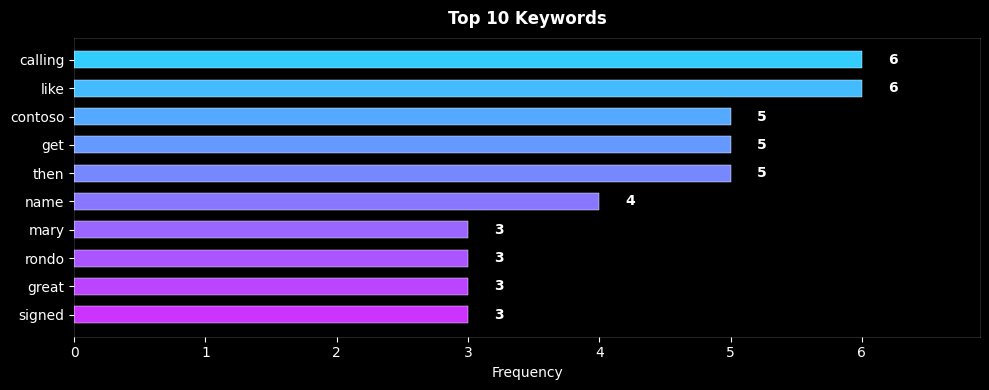

In [17]:
if phrases:
    # Combine all text
    all_text = " ".join(p.get("text", "") for p in phrases).lower()
    stop_words = {
        "a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "for",
        "of", "is", "it", "i", "you", "we", "he", "she", "they", "my", "your",
        "our", "this", "that", "with", "be", "was", "are", "have", "has", "do",
        "not", "no", "yes", "ok", "yeah", "so", "um", "uh", "well", "just",
        "can", "will", "would", "could", "please", "thank", "thanks", "also",
        "been", "did", "does", "got", "its", "let", "may", "much", "than",
        "too"
    }
    words = re.findall(r"\b[a-z]{3,}\b", all_text)
    filtered = [w for w in words if w not in stop_words]
    top_words = Counter(filtered).most_common(20)
    total_kw = len(filtered)
    unique_kw = len(set(filtered))

    display(Markdown("### 💬 Top 20 Keywords"))

    # Stats bar
    display(
        HTML(
            f'<div style="display:flex;gap:20px;background:#111;padding:10px 16px;'
            f'border-radius:8px;margin-bottom:12px">'
            f'<span style="color:#aaa;font-size:12px">📝 Total words: '
            f'<strong style="color:white">{len(words)}</strong></span>'
            f'<span style="color:#aaa;font-size:12px">🔑 After filtering: '
            f'<strong style="color:white">{total_kw}</strong></span>'
            f'<span style="color:#aaa;font-size:12px">🎯 Unique keywords: '
            f'<strong style="color:white">{unique_kw}</strong></span>'
            f'<span style="color:#aaa;font-size:12px">🚫 Stopwords removed: '
            f'<strong style="color:white">{len(words) - total_kw}</strong></span>'
            f'</div>'))

    # Word cloud pills with gradient
    max_cnt = top_words[0][1] if top_words else 1
    pills = ""
    colors = plt.cm.cool(np.linspace(0.2, 0.9, len(top_words)))
    for rank, ((word, cnt), col) in enumerate(zip(top_words, colors), 1):
        rgb = f"rgb({int(col[0]*255)},{int(col[1]*255)},{int(col[2]*255)})"
        sz = 12 + int(8 * cnt / max_cnt)
        pct = cnt / total_kw * 100
        pills += (
            f'<span style="background:{rgb}22;color:{rgb};border:1px solid {rgb}66;'
            f'padding:5px 12px;border-radius:16px;margin:4px;font-size:{sz}px;'
            f'display:inline-block;font-weight:600;transition:all 0.2s">'
            f'{word} <sup style="font-size:9px;opacity:0.7">{cnt}</sup>'
            f'</span>')
    display(
        HTML(
            f'<div style="line-height:2.4;margin:10px 0;padding:16px;'
            f'background:#0a0a0a;border-radius:10px;border:1px solid #222">{pills}</div>'
        ))

    # Horizontal bar chart
    top10 = top_words[:10]
    fig, ax = plt.subplots(figsize=(10, 4), facecolor="black")
    ax.set_facecolor("black")

    words_list = [w for w, _ in top10][::-1]
    counts = [c for _, c in top10][::-1]
    bar_colors = plt.cm.cool(np.linspace(0.8, 0.2, len(top10)))

    bars = ax.barh(words_list,
                   counts,
                   color=bar_colors,
                   edgecolor="white",
                   linewidth=0.3,
                   height=0.6)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_width() + 0.2,
                bar.get_y() + bar.get_height() / 2,
                f"{val}",
                va="center",
                color="white",
                fontsize=10,
                fontweight="bold")

    ax.set_xlabel("Frequency", color="white", fontsize=10)
    ax.set_title("Top 10 Keywords",
                 color="white",
                 fontsize=12,
                 pad=10,
                 fontweight="bold")
    ax.tick_params(colors="white", labelsize=10)
    for spine in ax.spines.values():
        spine.set_color("#ffffff22")
    ax.set_xlim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.savefig("keywords.png",
                dpi=150,
                bbox_inches="tight",
                facecolor="black")
    plt.show()

## Module 3 — 📞 Call Center Intelligence (`prebuilt-callCenter`)
### Agent/customer role detection · Call summary · Sentiment · Topics · Entities

`prebuilt-callCenter` is purpose-built for **contact center analytics**. Beyond the transcript, it automatically extracts:

| Field | Description |
|-------|-------------|
| **Summary** | End-to-end call narrative |
| **Sentiment** | Overall call sentiment (positive / neutral / negative) |
| **AgentRating** | AI-estimated agent performance rating |
| **CallResolution** | Was the issue resolved? |
| **TopArticles** | Top 5 knowledge base articles referenced |
| **Companies** | Companies mentioned during the call |
| **People** | Named people and their roles |
| **SpeakerRole** | Maps speakers to `Agent` or `Customer` |

> 🏢 **Use cases:** QA automation · compliance monitoring · CSAT prediction · knowledge gap detection

> 📌 Covers **100% of calls** vs ~5% with manual sampling


In [18]:
# Run prebuilt-callCenter
callcenter_result = analyze("prebuilt-callCenter", AUDIO_URL,
                            "prebuilt-callCenter")


[prebuilt-callCenter] Analyzer: prebuilt-callCenter
   Input  : Call1_separated_16k_health_insurance.wav
  Job submitted: b34b8704-a31d-4641-9c47-0d67...
  [  0.4s] Running...
  [  3.9s] Running...
  [  7.3s] Running...
  [ 10.7s] Running...
  [ 14.2s] Running...
  [ 17.6s] Running...
  Completed in 21.1s


In [19]:
fields = get_fields(callcenter_result)
phrases = get_phrases(callcenter_result)

display(Markdown("### 📞 Call Center Intelligence Report"))

# Summary card
summary = field_str(fields, "Summary")
if summary and summary != "--":
    display(
        HTML(
            '<div style="background:#eaf7f5;border-left:5px solid #065143;'
            'padding:14px 18px;border-radius:6px;margin:12px 0">'
            f'<strong>🤖 Call Summary</strong><br><br>'
            f'<span style="font-size:13px;line-height:1.6">{summary}</span></div>'
        ))

# Key metrics row
metric_fields = [
    ("Sentiment", "Sentiment", "😊"),
    ("AgentRating", "Agent Rating", "⭐"),
    ("CallResolution", "Resolved", "✅"),
    ("CallReason", "Call Reason", "📋"),
    ("Language", "Language", "🌐"),
]

metric_html = ""
for key, label, icon in metric_fields:
    val = field_str(fields, key)
    if val and val != "--":
        col = {
            "positive": "#107C10",
            "negative": "#D83B01",
            "neutral": "#666"
        }.get(val.lower(), "#065143")
        metric_html += (
            f'<div style="background:#f5fbfa;border:1px solid #065143;border-radius:8px;'
            f'padding:12px 16px;min-width:130px;text-align:center">'
            f'<div style="font-size:22px">{icon}</div>'
            f'<div style="color:#065143;font-size:11px;margin-top:4px">{label}</div>'
            f'<div style="font-size:14px;font-weight:bold;color:{col};margin-top:2px">{val}</div>'
            f'</div>')

if metric_html:
    display(
        HTML(
            f'<div style="display:flex;gap:12px;flex-wrap:wrap;margin:12px 0">{metric_html}</div>'
        ))

# Speaker roles
role_map = {}
for p in phrases:
    spk = p.get("speaker", "")
    role = p.get("speakerRole", "")
    if spk and role:
        role_map[spk] = role

if role_map:
    display(Markdown("\n**🎤 Speaker Role Detection:**"))
    role_rows = [{"Speaker": k, "Role": v} for k, v in role_map.items()]
    display(styled(pd.DataFrame(role_rows), "#065143"))

# Arrays: articles, companies, people
for key, label, color, icon in [
    ("TopArticles", "Top Articles Referenced", "#1b3a4b", "📚"),
    ("Companies", "Companies Mentioned", "#6b4226", "🏢"),
    ("People", "People Mentioned", "#4a1942", "👤"),
]:
    val = field_str(fields, key)
    if val and val != "--":
        items = [v.strip() for v in val.split(",") if v.strip()]
        if items:
            pills = " ".join(
                f'<span style="background:{color};color:white;padding:3px 10px;'
                f'border-radius:12px;margin:3px;font-size:12px;display:inline-block">{v}</span>'
                for v in items)
            display(Markdown(f"\n**{icon} {label}:**"))
            display(HTML(f'<div style="margin:6px 0">{pills}</div>'))

### 📞 Call Center Intelligence Report


**🏢 Companies Mentioned:**

## Module 4 — 🧠 Custom Call Center Analyzer
### Extract any business-specific insight from call recordings

Build a **custom audio analyzer** with a domain-specific field schema. Field descriptions guide the AI model like natural-language prompts — no training data, no labeling.

This module creates a **Customer Experience (CX) Quality Analyzer** with fields:
- `CustomerSentiment` — positive / neutral / negative / frustrated
- `AgentEmpathy` — rated 1–5
- `IssueCategory` — billing, technical, service, complaint, inquiry
- `ActionItems` — list of follow-up actions committed to
- `ComplianceFlags` — regulatory or script compliance issues
- `NPSPrediction` — estimated Net Promoter Score (0–5)
- `Escalation` — boolean: was escalation requested?
- `ProductsMentioned` — products or services discussed

In [20]:
cx_schema = {
    "description":
    "Customer Experience quality analyzer for call center recordings",
    "baseAnalyzerId": "prebuilt-audio",
    "models": {
        "completion": "gpt-4.1-mini"
    },
    "fieldSchema": {
        "fields": {
            "CustomerSentiment": {
                "type":
                "string",
                "method":
                "classify",
                "enum": ["positive", "neutral", "negative", "frustrated"],
                "description":
                "Overall emotional state of the customer during the call"
            },
            "AgentEmpathy": {
                "type": "string",
                "method": "classify",
                "enum": ["excellent", "good", "fair", "poor"],
                "description": "Rate the agent empathy and professionalism"
            },
            "IssueCategory": {
                "type":
                "string",
                "method":
                "classify",
                "enum": [
                    "billing", "technical_support", "account_management",
                    "complaint", "general_inquiry", "cancellation",
                    "new_service"
                ],
                "description":
                "Primary issue category for this call"
            },
            "ActionItems": {
                "type": "array",
                "description":
                "Follow-up actions or commitments made during the call",
                "items": {
                    "type": "object",
                    "properties": {
                        "Action": {
                            "type": "string"
                        }
                    }
                }
            },
            "ComplianceFlags": {
                "type": "array",
                "description":
                "Any compliance concerns or script deviations noted",
                "items": {
                    "type": "object",
                    "properties": {
                        "Flag": {
                            "type": "string"
                        }
                    }
                }
            },
            "NPSPrediction": {
                "type":
                "string",
                "method":
                "classify",
                "enum": ["promoter", "passive", "detractor"],
                "description":
                "Predicted NPS category based on sentiment and resolution"
            },
            "EscalationRequested": {
                "type":
                "string",
                "method":
                "classify",
                "enum": ["true", "false"],
                "description":
                "Whether the customer requested escalation to a supervisor"
            },
            "ProductsMentioned": {
                "type": "array",
                "description":
                "Products or services discussed during the call",
                "items": {
                    "type": "object",
                    "properties": {
                        "Product": {
                            "type": "string"
                        }
                    }
                }
            },
            "CallResolutionStatus": {
                "type":
                "string",
                "method":
                "classify",
                "enum": ["resolved", "partial", "unresolved", "pending"],
                "description":
                "Whether the customer issue was resolved during this call"
            },
            "KeyQuote": {
                "type": "string",
                "method": "generate",
                "description":
                "The single most important quote from the customer"
            },
        }
    }
}

print(f"Schema fields: {list(cx_schema['fieldSchema']['fields'].keys())}")

Schema fields: ['CustomerSentiment', 'AgentEmpathy', 'IssueCategory', 'ActionItems', 'ComplianceFlags', 'NPSPrediction', 'EscalationRequested', 'ProductsMentioned', 'CallResolutionStatus', 'KeyQuote']


In [21]:
# -- Multilingual custom analyzer --
ml_schema = {
    "description":
    "Multilingual audio analyzer with per-phrase locale detection",
    "baseAnalyzerId": "prebuilt-audio",
    "models": {
        "completion": "gpt-4.1-mini"
    },
    "fieldSchema": {
        "fields": {
            "PrimaryLanguage": {
                "type":
                "string",
                "method":
                "generate",
                "description":
                "The dominant language spoken in this recording (e.g., English, French, Spanish)"
            },
            "LanguagesMixed": {
                "type":
                "string",
                "method":
                "classify",
                "enum": ["true", "false"],
                "description":
                "Whether multiple languages are detected in this recording"
            },
            "Summary": {
                "type": "string",
                "method": "generate",
                "description": "Brief summary of the conversation content"
            },
            "Topics": {
                "type": "array",
                "description": "Main topics discussed in the recording",
                "items": {
                    "type": "object",
                    "properties": {
                        "Topic": {
                            "type": "string",
                            "description": "A topic discussed in the recording"
                        }
                    }
                }
            },
        }
    }
}

print(f"Schema fields: {list(ml_schema['fieldSchema']['fields'].keys())}")

Schema fields: ['PrimaryLanguage', 'LanguagesMixed', 'Summary', 'Topics']


In [22]:
CUSTOM_CC_ID = "cxQualityAnalyzerV1"
CUSTOM_ML_ID = "audioMultilingualAnalyzerV1"

In [23]:
# -- Create CX custom analyzer --
print("Creating CX Quality Analyzer...")
create_analyzer(CUSTOM_CC_ID, cx_schema)

Creating CX Quality Analyzer...
  Reusing : cxQualityAnalyzerV1


In [24]:
# -- Run CX extraction --
cx_result = analyze(CUSTOM_CC_ID, AUDIO_URL, "CX Quality Analyzer")


[CX Quality Analyzer] Analyzer: cxQualityAnalyzerV1
   Input  : Call1_separated_16k_health_insurance.wav
  Job submitted: c19c615c-32b0-4154-adff-11ce...
  [  0.4s] Running...
  [  3.9s] Running...
  [  7.3s] Running...
  [ 10.7s] Running...
  [ 14.2s] Running...
  [ 17.6s] Running...
  Completed in 21.1s


In [25]:
fields = get_fields(cx_result)

display(Markdown("### 🧠 Customer Experience Quality Analysis"))

if not fields:
    banner(
        "No fields extracted. Replace AUDIO_URL with a real call recording for best results.",
        icon="⚠️",
        color="#D83B01")
else:
    # Scalar fields as cards
    card_fields = [
        ("CustomerSentiment", "Customer Sentiment", "😊"),
        ("AgentEmpathy", "Agent Empathy", "🤝"),
        ("IssueCategory", "Issue Category", "📋"),
        ("NPSPrediction", "NPS Prediction", "📊"),
        ("EscalationRequested", "Escalation", "🚨"),
        ("CallResolutionStatus", "Resolution", "✅"),
    ]
    sent_colors = {
        "positive": "#107C10",
        "neutral": "#666",
        "negative": "#D83B01",
        "frustrated": "#C7500A",
        "promoter": "#107C10",
        "passive": "#FFC83D",
        "detractor": "#D83B01",
        "resolved": "#107C10",
        "partial": "#FFC83D",
        "unresolved": "#D83B01",
        "pending": "#666",
        "excellent": "#107C10",
        "good": "#0078D4",
        "fair": "#FFC83D",
        "poor": "#D83B01",
    }
    card_html = ""
    for key, label, icon in card_fields:
        val = field_str(fields, key)
        if val and val != "--":
            col = sent_colors.get(val.lower(), "#065143")
            card_html += (
                f'<div style="background:#f5fbfa;border:1px solid #aad9d4;border-radius:8px;'
                f'padding:12px 16px;min-width:130px;text-align:center">'
                f'<div style="font-size:22px">{icon}</div>'
                f'<div style="color:#065143;font-size:11px;margin-top:4px">{label}</div>'
                f'<div style="font-size:13px;font-weight:bold;color:{col};margin-top:2px">{val}</div>'
                f'</div>')
    if card_html:
        display(
            HTML(
                f'<div style="display:flex;gap:10px;flex-wrap:wrap;margin:12px 0">{card_html}</div>'
            ))

    # Array fields
    for key, label, color, icon in [
        ("ActionItems", "Action Items", "#065143", "✅"),
        ("ComplianceFlags", "Compliance Flags", "#D83B01", "⚠️"),
        ("ProductsMentioned", "Products Mentioned", "#1b3a4b", "📦"),
    ]:
        val = field_str(fields, key)
        if val and val != "--":
            items = [v.strip() for v in val.split(",") if v.strip()]
            if items:
                pills = " ".join(
                    f'<span style="background:{color};color:white;padding:3px 10px;'
                    f'border-radius:12px;margin:3px;font-size:12px;display:inline-block">{v}</span>'
                    for v in items)
                display(Markdown(f"\n**{icon} {label}:**"))
                display(HTML(f'<div style="margin:6px 0">{pills}</div>'))

    # Key quote
    kq = field_str(fields, "KeyQuote")
    if kq and kq != "--":
        display(
            HTML(
                '<div style="background:#e8f5f3;border-left:4px solid #065143;'
                'padding:12px 16px;margin:12px 0;border-radius:4px;font-style:italic;color:#333">'
                f'"“{kq}”"</div>'))

### 🧠 Customer Experience Quality Analysis

## Module 5 — 🗺️ Multilingual Detection & Language Analytics
### Auto-detect language per phrase · Mixed-language calls

Azure Content Understanding supports **multilingual transcription** — it can detect and transcribe different languages within a single recording, phrase by phrase.

This module creates a custom analyzer with explicit multilingual configuration and analyzes the language distribution across the transcript.

> 🌐 No language pre-configuration needed — set `locales: []` to let the model auto-detect


In [26]:
# -- Multilingual custom analyzer --
ml_schema = {
    "description":
    "Multilingual audio analyzer with per-phrase locale detection",
    "baseAnalyzerId": "prebuilt-audio",
    "models": {
        "completion": "gpt-4.1-mini"
    },
    "fieldSchema": {
        "fields": {
            "PrimaryLanguage": {
                "type":
                "string",
                "method":
                "generate",
                "description":
                "The dominant language spoken in this recording (e.g., English, French, Spanish)"
            },
            "LanguagesMixed": {
                "type":
                "string",
                "method":
                "classify",
                "enum": ["true", "false"],
                "description":
                "Whether multiple languages are detected in this recording"
            },
            "Summary": {
                "type": "string",
                "method": "generate",
                "description": "Brief summary of the conversation content"
            },
            "Topics": {
                "type": "array",
                "description": "Main topics discussed in the recording",
                "items": {
                    "type": "object",
                    "properties": {
                        "Topic": {
                            "type": "string",
                            "description": "A topic discussed in the recording"
                        }
                    }
                }
            },
        }
    }
}

print("Creating multilingual analyzer...")
create_analyzer(CUSTOM_ML_ID, ml_schema)

Creating multilingual analyzer...
  Reusing : audioMultilingualAnalyzerV1


In [27]:
# -- Run multilingual analysis --
ml_result = analyze(CUSTOM_ML_ID, AUDIO_URL, "Multilingual Analyzer")


[Multilingual Analyzer] Analyzer: audioMultilingualAnalyzerV1
   Input  : Call1_separated_16k_health_insurance.wav
  Job submitted: 57c39336-3a07-4587-8abe-84bb...
  [  0.4s] Running...
  [  3.9s] Running...
  [  7.3s] Running...
  [ 10.8s] Running...
  [ 14.3s] Running...
  [ 17.7s] Running...
  Completed in 21.2s


In [28]:
# -- Language distribution analysis --
phrases = get_phrases(ml_result)
fields = get_fields(ml_result)

display(Markdown("### 🗺️ Language Analytics"))

# Field results
primary_lang = field_str(fields, "PrimaryLanguage")
mixed = field_str(fields, "LanguagesMixed")
topics = field_str(fields, "Topics")
summary = field_str(fields, "Summary")

info_html = ""
for label, val, icon in [
    ("Primary Language", primary_lang, "🌐"),
    ("Mixed Languages", mixed, "🔄"),
]:
    if val and val != "--":
        info_html += (
            f'<div style="background:#eaf7f5;padding:10px 16px;border-radius:6px;'
            f'margin:6px 0;font-size:13px"><strong>{icon} {label}:</strong> {val}</div>'
        )
display(
    HTML(
        info_html or
        "<p>No language fields available -- try a multilingual audio file.</p>"
    ))

if summary and summary != "--":
    display(
        HTML(
            '<div style="background:#eaf7f5;border-left:5px solid #065143;padding:14px;'
            'border-radius:6px;margin:10px 0"><strong>Summary:</strong><br>'
            f'<em style="font-size:13px">{summary}</em></div>'))

if topics and topics != "--":
    topic_list = [t.strip() for t in topics.split(",") if t.strip()]
    pills = " ".join(
        f'<span style="background:#065143;color:white;padding:3px 10px;'
        f'border-radius:12px;margin:3px;font-size:12px">{t}</span>'
        for t in topic_list)
    display(Markdown("**Topics:**"))
    display(HTML(f'<div style="margin:6px 0">{pills}</div>'))

# Per-phrase locale breakdown
locale_counts = Counter(
    p.get("locale", "unknown") for p in phrases if p.get("locale"))
if locale_counts:
    display(Markdown(f"\n**Detected locales across {len(phrases)} phrases:**"))
    loc_rows = sorted([{
        "Locale": k,
        "Phrases": v,
        "Share": f"{v/len(phrases)*100:.0f}%"
    } for k, v in locale_counts.items()],
                      key=lambda x: -x["Phrases"])
    display(styled(pd.DataFrame(loc_rows), "#1b3a4b"))

    if len(locale_counts) > 1:
        fig, ax = plt.subplots(figsize=(7, 4), facecolor="#0d1b2a")
        ax.set_facecolor("#0d1b2a")
        langs = [r["Locale"] for r in loc_rows]
        counts = [r["Phrases"] for r in loc_rows]
        cols = plt.cm.Set2(np.linspace(0, 1, len(langs)))
        wedges, texts, autos = ax.pie(counts,
                                      labels=langs,
                                      colors=cols,
                                      autopct="%1.0f%%",
                                      startangle=90,
                                      textprops={
                                          "color": "white",
                                          "fontsize": 10
                                      })
        ax.set_title("Language Distribution per Phrase",
                     color="white",
                     fontsize=12,
                     pad=12)
        plt.tight_layout()
        plt.savefig("language_distribution.png",
                    dpi=150,
                    bbox_inches="tight",
                    facecolor="#0d1b2a")
        plt.show()
    else:
        banner(
            f"Single language detected: <strong>{list(locale_counts.keys())[0]}</strong>. Use a multilingual audio file to see mixed-language analysis.",
            icon="🌐",
            color="#1b3a4b")

### 🗺️ Language Analytics

## Module 6 — 📊 Speech Timeline & Pace Analytics
### Visualize conversation dynamics over time

This module transforms the raw `transcriptPhrases` timing data into a rich set of visualizations:
- **Speech activity heatmap** — who was speaking at every second
- **Turn-taking timeline** — conversation flow between speakers
- **Silence detection** — gaps in conversation > 1 second
- **Words per minute** — speaking pace per speaker
- **Phrase duration distribution** — short vs. long utterances


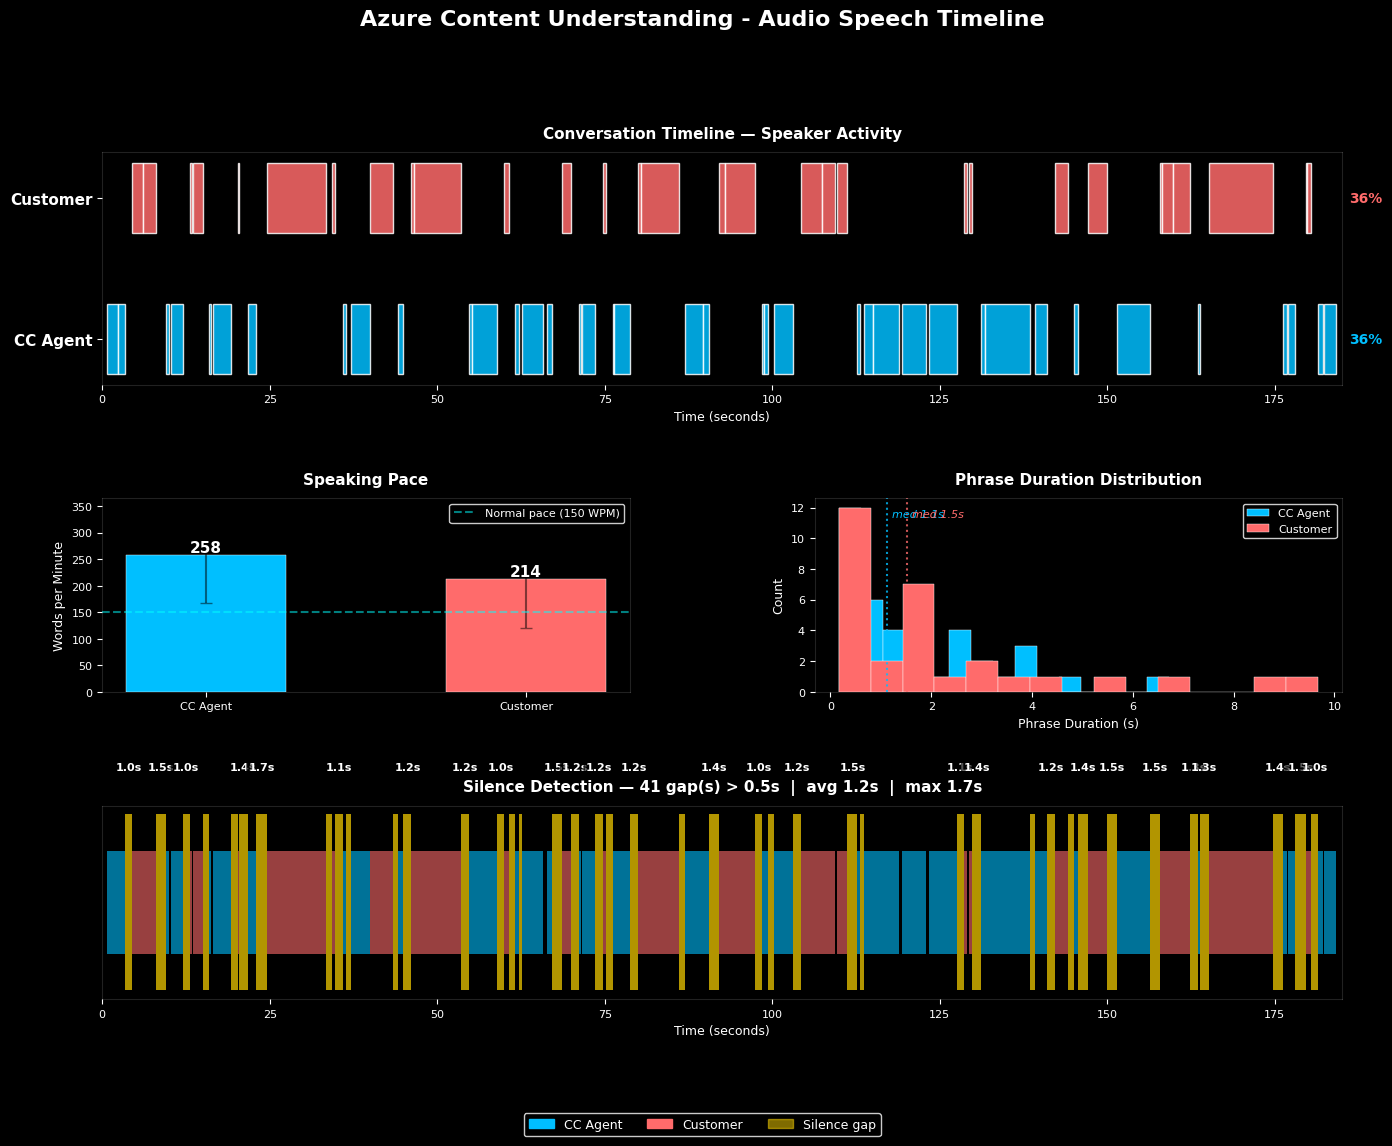

Total duration: 185.1s | Phrases: 69 | Speakers: 2 | Silence gaps: 41 | Avg gap: 1.2s | Max gap: 1.7s


In [30]:
# -- Build speech timeline from prebuilt-audioSearch result --
phrases = get_phrases(audio_result)
contents = get_contents(audio_result)
total_ms = contents[0].get("endTimeMs", 0) if contents else 0
total_s = total_ms / 1000

# Speaker rename mapping
spk_rename = {"Speaker 1": "CC Agent", "Speaker 2": "Customer"}
for p in phrases:
    p["speaker"] = spk_rename.get(p.get("speaker", ""), p.get("speaker", ""))

if not phrases or total_s == 0:
    print("No phrase data available for timeline visualization.")
else:
    speakers = sorted(set(p.get("speaker", "?") for p in phrases))
    spk_colors = {
        "CC Agent": "#00BFFF",
        "Customer": "#FF6B6B",
        "Speaker 3": "#AB47BC",
        "Unknown": "white"
    }
    for i, s in enumerate(speakers):
        if s not in spk_colors:
            spk_colors[s] = ["#6b4226", "#4a1942", "#2196F3", "#E91E63"][i % 4]

    # Pre-compute per-speaker stats
    spk_stats = {}
    for p in phrases:
        spk = p.get("speaker", "?")
        dur = (p.get("endTimeMs", 0) - p.get("startTimeMs", 0)) / 1000
        wc = len(p.get("text", "").split())
        spk_stats.setdefault(spk, {"phrases": 0, "words": 0, "time_s": 0.0})
        spk_stats[spk]["phrases"] += 1
        spk_stats[spk]["words"] += wc
        spk_stats[spk]["time_s"] += dur

    fig = plt.figure(figsize=(16, 11), facecolor="black")
    gs = gridspec.GridSpec(3,
                           2,
                           hspace=0.55,
                           wspace=0.35,
                           figure=fig,
                           height_ratios=[1.2, 1, 1])

    # ── Helper for consistent dark axes ──
    def style_ax(ax, title="", xlabel="", ylabel=""):
        ax.set_facecolor("black")
        ax.set_title(title,
                     color="white",
                     fontsize=11,
                     pad=10,
                     fontweight="bold")
        if xlabel: ax.set_xlabel(xlabel, color="white", fontsize=9)
        if ylabel: ax.set_ylabel(ylabel, color="white", fontsize=9)
        ax.tick_params(colors="white", labelsize=8)
        for spine in ax.spines.values():
            spine.set_color("#ffffff22")

    # ══════════════════════════════════════════════════
    # 1. TIMELINE SWIM LANES
    # ══════════════════════════════════════════════════
    ax1 = fig.add_subplot(gs[0, :])
    style_ax(ax1,
             title="Conversation Timeline — Speaker Activity",
             xlabel="Time (seconds)")
    spk_y = {spk: i for i, spk in enumerate(speakers)}

    for p in phrases:
        spk = p.get("speaker", "?")
        s_s = p.get("startTimeMs", 0) / 1000
        e_s = p.get("endTimeMs", 0) / 1000
        y = spk_y.get(spk, 0)
        col = spk_colors.get(spk, "#aaa")
        ax1.barh(y,
                 e_s - s_s,
                 left=s_s,
                 height=0.5,
                 color=col,
                 alpha=0.85,
                 edgecolor=(1, 1, 1, 0.1))

    ax1.set_yticks(list(spk_y.values()))
    ax1.set_yticklabels(list(spk_y.keys()),
                        color="white",
                        fontsize=11,
                        fontweight="bold")
    ax1.set_xlim(0, total_s)

    # Add speaker speaking-time % annotations on the right
    for spk, y in spk_y.items():
        pct = spk_stats.get(spk, {}).get("time_s", 0) / total_s * 100
        ax1.text(total_s + 1,
                 y,
                 f"{pct:.0f}%",
                 color=spk_colors.get(spk, "white"),
                 fontsize=10,
                 fontweight="bold",
                 va="center")

    # ══════════════════════════════════════════════════
    # 2. WORDS PER MINUTE
    # ══════════════════════════════════════════════════
    ax2 = fig.add_subplot(gs[1, 0])
    style_ax(ax2, title="Speaking Pace", ylabel="Words per Minute")

    wpm_data = {}
    for p in phrases:
        spk = p.get("speaker", "?")
        dur_min = (p.get("endTimeMs", 0) - p.get("startTimeMs", 0)) / 1000 / 60
        wc = len(p.get("text", "").split())
        if dur_min > 0:
            wpm_data.setdefault(spk, []).append(wc / dur_min)
    wpm_avgs = {s: np.mean(v) for s, v in wpm_data.items()}
    wpm_stds = {s: np.std(v) for s, v in wpm_data.items()}

    bars = ax2.bar(list(wpm_avgs.keys()),
                   list(wpm_avgs.values()),
                   yerr=[wpm_stds.get(s, 0) for s in wpm_avgs],
                   capsize=4,
                   error_kw={
                       "color": "white",
                       "alpha": 0.5
                   },
                   color=[spk_colors.get(s, "#aaa") for s in wpm_avgs],
                   width=0.5,
                   edgecolor="white",
                   linewidth=0.3)
    for bar, val in zip(bars, wpm_avgs.values()):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f"{val:.0f}",
                 ha="center",
                 color="white",
                 fontsize=11,
                 fontweight="bold")
    ax2.axhline(150,
                color="cyan",
                linestyle="--",
                alpha=0.5,
                label="Normal pace (150 WPM)")
    ax2.legend(facecolor="black",
               labelcolor="white",
               fontsize=8,
               edgecolor="#ffffff33")

    # ══════════════════════════════════════════════════
    # 3. PHRASE DURATION DISTRIBUTION
    # ══════════════════════════════════════════════════
    ax3 = fig.add_subplot(gs[1, 1])
    style_ax(ax3,
             title="Phrase Duration Distribution",
             xlabel="Phrase Duration (s)",
             ylabel="Count")

    for spk in speakers:
        durs = [(p.get("endTimeMs", 0) - p.get("startTimeMs", 0)) / 1000
                for p in phrases if p.get("speaker") == spk]
        if durs:
            ax3.hist(durs,
                     bins=15,
                     alpha=1.0,
                     color=spk_colors.get(spk, "#aaa"),
                     label=spk,
                     edgecolor="white",
                     linewidth=0.3)
            # Add median line
            med = np.median(durs)
            ax3.axvline(med,
                        color=spk_colors.get(spk, "#aaa"),
                        linestyle=":",
                        alpha=0.8,
                        linewidth=1.5)
            ax3.text(med + 0.1,
                     ax3.get_ylim()[1] * 0.9,
                     f"med {med:.1f}s",
                     color=spk_colors.get(spk, "white"),
                     fontsize=8,
                     fontstyle="italic")

    ax3.legend(facecolor="black",
               labelcolor="white",
               fontsize=8,
               edgecolor="#ffffff33")

    # ══════════════════════════════════════════════════
    # 4. SILENCE GAP DETECTION
    # ══════════════════════════════════════════════════
    ax4 = fig.add_subplot(gs[2, :])
    sorted_p = sorted(phrases, key=lambda x: x.get("startTimeMs", 0))
    gaps = []
    for i in range(1, len(sorted_p)):
        gap_s = (sorted_p[i].get("startTimeMs", 0) -
                 sorted_p[i - 1].get("endTimeMs", 0)) / 1000
        if gap_s > 0.5:
            mid = (sorted_p[i - 1].get("endTimeMs", 0) / 1000 +
                   sorted_p[i].get("startTimeMs", 0) / 1000) / 2
            gaps.append((mid, gap_s))

    avg_gap = np.mean([g for _, g in gaps]) if gaps else 0
    max_gap = max([g for _, g in gaps]) if gaps else 0
    style_ax(
        ax4,
        title=
        f"Silence Detection — {len(gaps)} gap(s) > 0.5s  |  avg {avg_gap:.1f}s  |  max {max_gap:.1f}s",
        xlabel="Time (seconds)")

    # Speech blocks
    for p in phrases:
        s_s = p.get("startTimeMs", 0) / 1000
        e_s = p.get("endTimeMs", 0) / 1000
        col = spk_colors.get(p.get("speaker", "?"), "#aaa")
        ax4.barh(0, e_s - s_s, left=s_s, height=0.35, color=col, alpha=0.6)

    # Silence gaps with gradient intensity
    for mid, g in gaps:
        intensity = min(g / 5.0, 1.0)
        gap_color = (1.0, 0.84, 0.0, max(0.15, intensity))
        ax4.barh(0,
                 g,
                 left=mid - g / 2,
                 height=0.6,
                 color=gap_color,
                 alpha=0.7)
        if g > 1.0:
            ax4.text(mid,
                     0.45,
                     f"{g:.1f}s",
                     ha="center",
                     color="white",
                     fontsize=8,
                     fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.15",
                               facecolor="black",
                               alpha=0.6))

    ax4.set_xlim(0, total_s)
    ax4.set_yticks([])

    # ── Title & save ──
    fig.suptitle("Azure Content Understanding - Audio Speech Timeline",
                 color="white",
                 fontsize=16,
                 y=1.01,
                 fontweight="bold")

    # Legend
    legend_patches = [
        mpatches.Patch(color=spk_colors.get(s, "#aaa"), label=s)
        for s in speakers
    ]
    legend_patches.append(
        mpatches.Patch(color=(1.0, 0.84, 0.0, 0.5), label="Silence gap"))
    fig.legend(handles=legend_patches,
               loc="lower center",
               ncol=len(legend_patches),
               facecolor="black",
               labelcolor="white",
               edgecolor="#ffffff33",
               fontsize=9,
               bbox_to_anchor=(0.5, -0.02))

    plt.savefig("speech_timeline.png",
                dpi=300,
                bbox_inches="tight",
                facecolor="black")
    plt.show()

    print(f"Total duration: {total_s:.1f}s | Phrases: {len(phrases)} | "
          f"Speakers: {n_spk} | Silence gaps: {len(gaps)} | "
          f"Avg gap: {avg_gap:.1f}s | Max gap: {max_gap:.1f}s")